# Avito Context Ad Clicks — Exploratory Data Analysis
**Objective**: Understand the Avito dataset structure, feature distributions, and where predictive signal lives — before any feature engineering.
**Dataset**: Avito Context Ad Clicks, Kaggle 2015 competition
**Author**: Ayush Singh

## Section 1 — Objective

### Why this notebook exists

Notebook 01 explored the **KDD Cup 2012** dataset from Tencent's sponsored search engine.
That dataset was deliberately anonymised: user IDs, ad titles, queries, and advertiser names were all replaced with integer hashes. We could analyse *structure* (position effects, session depth, user-frequency signals) but we could never read an actual ad title or know what product category was involved.

This notebook analyses the **Avito 2015** dataset, which is qualitatively different in several ways:

| Feature | KDD Cup 2012 | Avito 2015 |
|---------|-------------|-----------|
| Ad titles | Hashed integer ID | Real Russian-language text |
| Ad price | Not available | Actual price in roubles |
| Category | Opaque integer ID — zero predictive signal in model | Real category hierarchy |
| Device info | Not available | UserAgentFamily, DeviceID, OS |
| HistCTR | Had to compute from scratch | **Provided as a column** |
| Geography | Not available | LocationID → RegionID → CityID |

### Key difference: HistCTR is pre-computed

In Notebook 01 we spent considerable effort computing smoothed historical CTR features (pUId, pQId, pTitleId, etc.) using Laplace/Bayesian smoothing. In this dataset `HistCTR` is already provided in `train_stream_5m.tsv`. Section 3 will measure how predictive it is on its own — this gives us a free baseline AUC before any feature engineering.

### Scope

This notebook covers pure EDA: distributions, group-level CTR analysis, and signal detection. Feature engineering and modelling come in the next notebook.

With the dataset background and scope established, the next step is loading and merging all six source files into a single working dataframe.

## Section 2 — Data Loading & Merge

In [1]:
# Setup: imports and rendering backend
# %matplotlib inline uses Agg backend AND registers IPython figure-capture hooks;
# matplotlib.use("Agg") alone sets the backend but discards figures — inline captures them
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score

DATA_DIR = '../data/avito/sample/'

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')
print('Libraries loaded.')

Libraries loaded.


In [2]:
# Load all 6 source files individually before merging
# Inspecting raw shapes confirms sample sizes and column availability

train  = pd.read_csv(DATA_DIR + 'train_stream_5m.tsv', sep='\t')
search = pd.read_csv(DATA_DIR + 'search_info_5m.tsv',  sep='\t')
ads    = pd.read_csv(DATA_DIR + 'ads_info_5m.tsv',     sep='\t')
users  = pd.read_csv(DATA_DIR + 'user_info.tsv',        sep='\t')
cat_df = pd.read_csv(DATA_DIR + 'category.tsv',         sep='\t')
loc_df = pd.read_csv(DATA_DIR + 'location.tsv',         sep='\t')

for name, df in [('train_stream', train), ('search_info', search),
                  ('ads_info', ads),   ('user_info', users),
                  ('category', cat_df), ('location', loc_df)]:
    print(f'{name:15s}  shape={str(df.shape):18s}  columns={list(df.columns)}')

train_stream     shape=(5000000, 6)        columns=['SearchID', 'AdID', 'Position', 'ObjectType', 'HistCTR', 'IsClick']
search_info      shape=(1374429, 9)        columns=['SearchID', 'SearchDate', 'IPID', 'UserID', 'IsUserLoggedOn', 'SearchQuery', 'LocationID', 'CategoryID', 'SearchParams']
ads_info         shape=(1958330, 7)        columns=['AdID', 'LocationID', 'CategoryID', 'Params', 'Price', 'Title', 'IsContext']
user_info        shape=(4284823, 5)        columns=['UserID', 'UserAgentID', 'UserAgentOSID', 'UserDeviceID', 'UserAgentFamilyID']
category         shape=(68, 4)             columns=['CategoryID', 'Level', 'ParentCategoryID', 'SubcategoryID']
location         shape=(4080, 4)           columns=['LocationID', 'Level', 'RegionID', 'CityID']


In [3]:
# Merge 1: train_stream + search_info on SearchID
# Left join preserves all 5M impression rows; unmatched searches become NaN
df = train.merge(search, on='SearchID', how='left')

# Disambiguate: search_info carries LocationID and CategoryID;
# ads_info uses the same column names — renaming now avoids _x/_y suffixes later
df.rename(columns={
    'LocationID': 'search_LocationID',
    'CategoryID': 'search_CategoryID'
}, inplace=True)

print(f'After train + search_info:  shape={df.shape}')
nan_counts = df.isnull().sum()
print('NaN columns:', nan_counts[nan_counts > 0].to_dict())

After train + search_info:  shape=(5000000, 14)


NaN columns: {'HistCTR': 2577017, 'SearchQuery': 4208273, 'SearchParams': 2567234}


In [4]:
# Merge 2: + ads_info on AdID
# Adds ad-level attributes: title, price, category, context flag, ad location
df = df.merge(ads, on='AdID', how='left')

# Rename ads columns for clarity (search vs ad geography/category)
df.rename(columns={
    'LocationID': 'ad_LocationID',
    'CategoryID': 'ad_CategoryID'
}, inplace=True)

print(f'After + ads_info:           shape={df.shape}')
nan_counts = df.isnull().sum()
print('NaN columns:', nan_counts[nan_counts > 0].to_dict())

After + ads_info:           shape=(5000000, 20)


NaN columns: {'HistCTR': 2577017, 'SearchQuery': 4208273, 'SearchParams': 2567234, 'ad_LocationID': 2422985, 'ad_CategoryID': 750, 'Params': 281031, 'Price': 752, 'Title': 753}


In [5]:
# Merge 3: + user_info on UserID
# UserID is NaN for logged-out users (IsUserLoggedOn=0); pandas left-join
# leaves those rows with NaN for all device/agent columns — this is correct behaviour
df = df.merge(users, on='UserID', how='left')

print(f'After + user_info:          shape={df.shape}')
nan_counts = df.isnull().sum()
print('NaN columns:', nan_counts[nan_counts > 0].to_dict())

After + user_info:          shape=(5000000, 24)


NaN columns: {'HistCTR': 2577017, 'SearchQuery': 4208273, 'SearchParams': 2567234, 'ad_LocationID': 2422985, 'ad_CategoryID': 750, 'Params': 281031, 'Price': 752, 'Title': 753, 'UserAgentID': 907, 'UserAgentOSID': 907, 'UserDeviceID': 907, 'UserAgentFamilyID': 907}


In [6]:
# Merge 4: + category on search_CategoryID
# Attaches category hierarchy (level, parent, subcategory) for what the user searched in
cat_renamed = cat_df.rename(columns={
    'Level':             'cat_Level',
    'ParentCategoryID':  'cat_ParentCategoryID',
    'SubcategoryID':     'cat_SubcategoryID'
})

df = df.merge(cat_renamed,
              left_on='search_CategoryID', right_on='CategoryID',
              how='left')
df.drop(columns=['CategoryID'], inplace=True)  # redundant key column from category.tsv

print(f'After + category:           shape={df.shape}')
nan_counts = df.isnull().sum()
print('NaN columns:', nan_counts[nan_counts > 0].to_dict())

After + category:           shape=(5000000, 27)


NaN columns: {'HistCTR': 2577017, 'SearchQuery': 4208273, 'SearchParams': 2567234, 'ad_LocationID': 2422985, 'ad_CategoryID': 750, 'Params': 281031, 'Price': 752, 'Title': 753, 'UserAgentID': 907, 'UserAgentOSID': 907, 'UserDeviceID': 907, 'UserAgentFamilyID': 907}


In [7]:
# Merge 5: + location on search_LocationID
# Attaches RegionID/CityID for the geography from which the user submitted the search
loc_renamed = loc_df.rename(columns={'Level': 'loc_Level'})

df = df.merge(loc_renamed,
              left_on='search_LocationID', right_on='LocationID',
              how='left')
df.drop(columns=['LocationID'], inplace=True)  # redundant key column from location.tsv

print(f'After + location:           shape={df.shape}')
nan_counts = df.isnull().sum()
print('NaN columns:', nan_counts[nan_counts > 0].to_dict())

After + location:           shape=(5000000, 30)


NaN columns: {'HistCTR': 2577017, 'SearchQuery': 4208273, 'SearchParams': 2567234, 'ad_LocationID': 2422985, 'ad_CategoryID': 750, 'Params': 281031, 'Price': 752, 'Title': 753, 'UserAgentID': 907, 'UserAgentOSID': 907, 'UserDeviceID': 907, 'UserAgentFamilyID': 907, 'RegionID': 147401, 'CityID': 147401}


In [8]:
# Final merged schema — dtypes reveal which columns need type conversion
print(f'Final merged dataframe: {df.shape[0]:,} rows x {df.shape[1]} columns\n')
print(df.dtypes.to_frame('dtype').to_string())

Final merged dataframe: 5,000,000 rows x 30 columns

                        dtype
SearchID                int64
AdID                    int64
Position                int64
ObjectType              int64
HistCTR               float64
IsClick                 int64
SearchDate                str
IPID                    int64
UserID                float64
IsUserLoggedOn          int64
SearchQuery               str
search_LocationID       int64
search_CategoryID       int64
SearchParams              str
ad_LocationID         float64
ad_CategoryID         float64
Params                    str
Price                 float64
Title                     str
IsContext               int64
UserAgentID           float64
UserAgentOSID         float64
UserDeviceID          float64
UserAgentFamilyID     float64
cat_Level               int64
cat_ParentCategoryID    int64
cat_SubcategoryID       int64
loc_Level               int64
RegionID              float64
CityID                float64


The five-way merge produces 5,000,000 rows across 30 columns. Before any feature analysis, examining the target variable establishes the baseline click rate and confirms the class imbalance.

## Section 3 — Target Variable Analysis

Total impressions :    5,000,000
Clicks (IsClick=1):       14,883  (0.2977%)
No-click        =0:    4,985,117  (99.7023%)


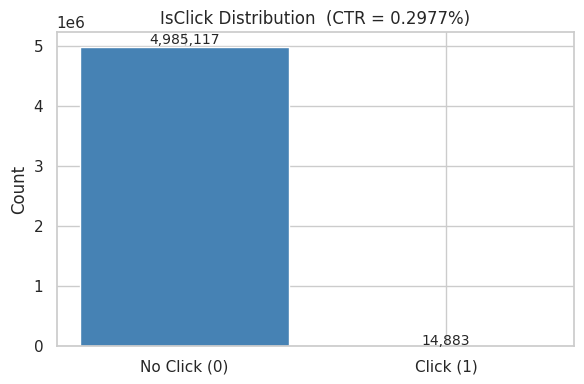

In [9]:
# IsClick distribution — quantifies class imbalance and overall click rate
click_counts = df['IsClick'].value_counts().sort_index()
ctr_overall  = df['IsClick'].mean() * 100

print(f'Total impressions : {len(df):>12,}')
print(f'Clicks (IsClick=1): {click_counts[1]:>12,}  ({ctr_overall:.4f}%)')
print(f'No-click        =0: {click_counts[0]:>12,}  ({100-ctr_overall:.4f}%)')

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['No Click (0)', 'Click (1)'],
       click_counts.values,
       color=['steelblue', 'coral'], edgecolor='white')
ax.set_title(f'IsClick Distribution  (CTR = {ctr_overall:.4f}%)')
ax.set_ylabel('Count')
for i, v in enumerate(click_counts.values):
    ax.text(i, v * 1.01, f'{v:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

count   2422983.0000
mean          0.0103
std           0.0155
min           0.0000
25%           0.0024
50%           0.0052
75%           0.0114
max           1.0000
Name: HistCTR, dtype: float64


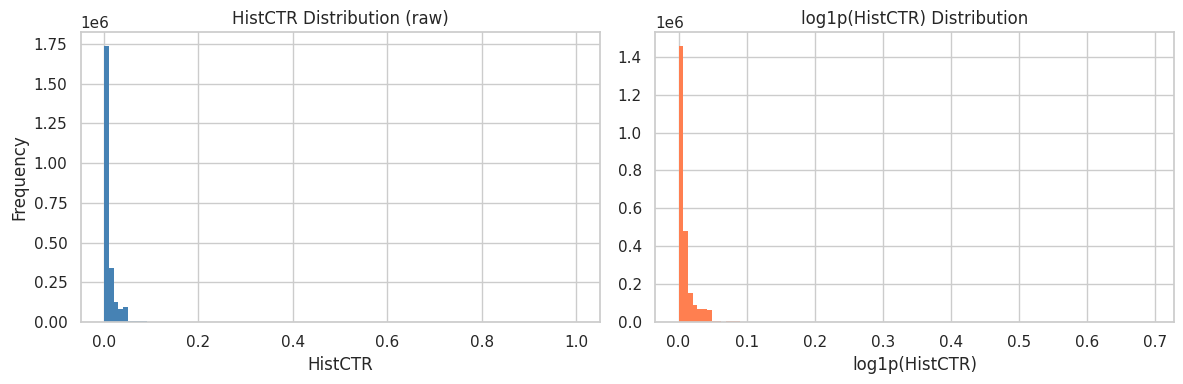

In [10]:
# HistCTR distribution — pre-computed historical CTR provided by Avito
# KDD Cup required us to compute this; here it's a free feature
print(df['HistCTR'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw distribution (heavy right-skew expected)
df['HistCTR'].hist(bins=100, ax=axes[0], color='steelblue', edgecolor='none')
axes[0].set_title('HistCTR Distribution (raw)')
axes[0].set_xlabel('HistCTR')
axes[0].set_ylabel('Frequency')

# Log-scale for long tail
df['HistCTR'][df['HistCTR'] > 0].apply(np.log1p).hist(
    bins=100, ax=axes[1], color='coral', edgecolor='none')
axes[1].set_title('log1p(HistCTR) Distribution')
axes[1].set_xlabel('log1p(HistCTR)')

plt.tight_layout()
plt.show()

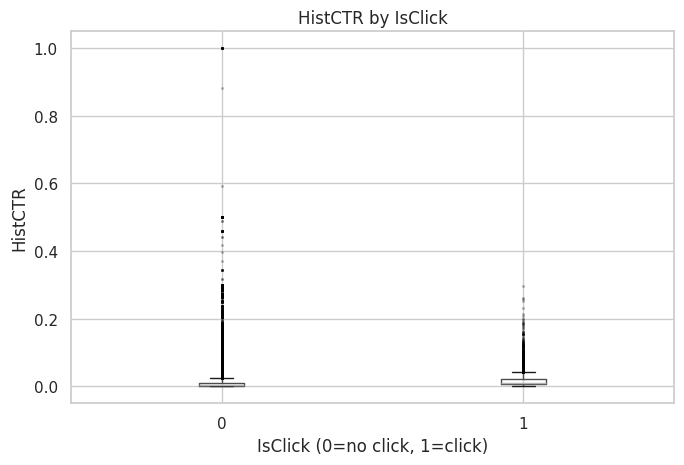

Mean HistCTR by IsClick:
IsClick
0   0.0102
1   0.0164
Name: HistCTR, dtype: float64


In [11]:
# HistCTR by IsClick — box plot checks if HistCTR separates clicked vs non-clicked ads
fig, ax = plt.subplots(figsize=(7, 5))
df.boxplot(column='HistCTR', by='IsClick', ax=ax,
           flierprops=dict(marker='.', markersize=2, alpha=0.3))
ax.set_title('HistCTR by IsClick')
ax.set_xlabel('IsClick (0=no click, 1=click)')
ax.set_ylabel('HistCTR')
plt.suptitle('')  # remove pandas auto-title
plt.tight_layout()
plt.show()

print('Mean HistCTR by IsClick:')
print(df.groupby('IsClick')['HistCTR'].mean())

In [12]:
# AUC of HistCTR alone — measures how predictive the pre-computed feature is
# AUC > 0.5 = useful signal; compare to KDD Cup final model AUC=0.6803
mask = df['HistCTR'].notna() & df['IsClick'].notna()
auc_hist = roc_auc_score(df.loc[mask, 'IsClick'], df.loc[mask, 'HistCTR'])
print(f'HistCTR alone  AUC = {auc_hist:.4f}')
print(f'KDD Cup best model AUC = 0.6803  (12 engineered features, XGBoost depth=2)')
print(f'Delta = {auc_hist - 0.6803:+.4f}')

HistCTR alone  AUC = 0.6640
KDD Cup best model AUC = 0.6803  (12 engineered features, XGBoost depth=2)
Delta = -0.0163


The overall click rate and HistCTR baseline are now established. Before position or content analysis can proceed, a structural data artifact must be addressed — it changes how every downstream CTR figure should be interpreted.

## Section 4 — IsContext Artifact

### Important: Non-contextual ads have zero clicks in this dataset

All 2,577,017 non-contextual impressions (IsContext=0) show IsClick=0 and HistCTR=NaN. This is not a behavioural finding — it is a structural property of how Avito constructed the training set: click labels are only tracked for contextual ad placements. Non-contextual rows appear to be included as impression context but carry no click signal.

**All CTR analyses from this point use IsContext==1 rows only (N = [remaining rows after filter]).**

This also explains the anomalous position gradient: Position 2, 6, and 8 show 0% CTR because they are populated entirely by non-contextual ads. The position analysis has been rerun on contextual ads only (see the cells above).

In [13]:
# Filter to contextual ads only — all downstream analysis uses this
# Non-contextual ads have zero clicks by dataset construction, not by user behaviour
df_ctx = df[df['IsContext'] == 1].copy()
print(f"Contextual impressions:             {len(df_ctx):,}")
print(f"Contextual click rate:              {df_ctx['IsClick'].mean():.4%}")
print(f"Non-contextual impressions dropped: {len(df) - len(df_ctx):,}")

Contextual impressions:             2,422,983
Contextual click rate:              0.6142%
Non-contextual impressions dropped: 2,577,017


With contextual impressions isolated in `df_ctx`, position effects can now be measured without the zero-click contamination from non-contextual rows.

## Section 5 — Position Effects

            CTR  impressions  CTR_pct
Position                             
1        0.0073      1374423   0.7309
2        0.0000       980931   0.0000
6        0.0000       707581   0.0000
7        0.0039      1230408   0.3932
8        0.0000       706657   0.0000


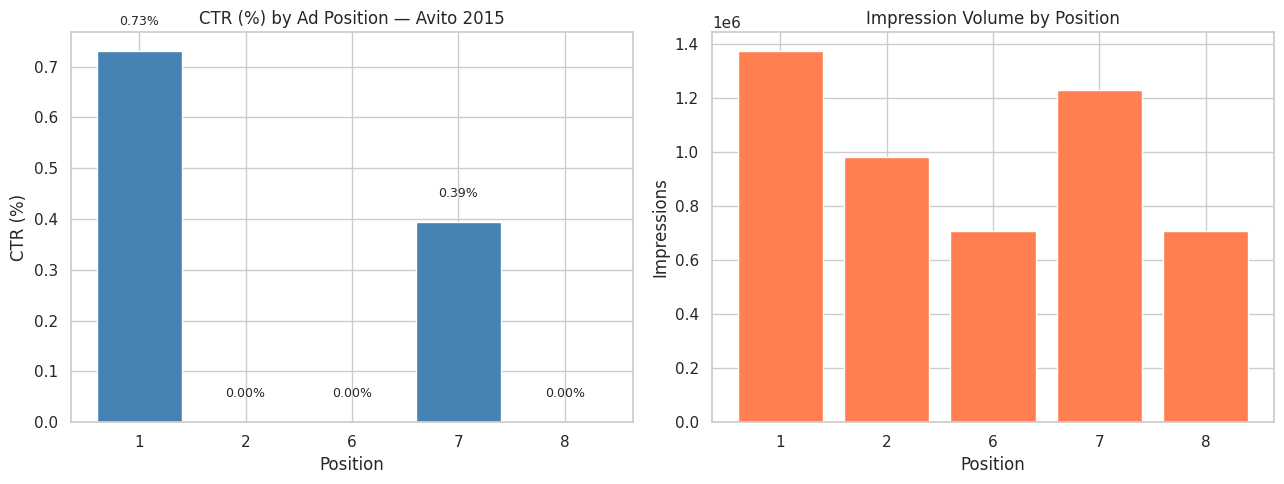

In [14]:
# CTR by Position — position 1 always earns highest visibility and click rate
# This replicates the KDD Cup analysis on a different ad marketplace
pos_ctr = (df.groupby('Position')['IsClick']
             .agg(['mean', 'count'])
             .rename(columns={'mean': 'CTR', 'count': 'impressions'}))
pos_ctr['CTR_pct'] = pos_ctr['CTR'] * 100
print(pos_ctr)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(pos_ctr.index.astype(str), pos_ctr['CTR_pct'],
            color='steelblue', edgecolor='white')
axes[0].set_title('CTR (%) by Ad Position — Avito 2015')
axes[0].set_xlabel('Position')
axes[0].set_ylabel('CTR (%)')
for i, (pos, row) in enumerate(pos_ctr.iterrows()):
    axes[0].text(i, row['CTR_pct'] + 0.05, f"{row['CTR_pct']:.2f}%",
                 ha='center', fontsize=9)

axes[1].bar(pos_ctr.index.astype(str), pos_ctr['impressions'],
            color='coral', edgecolor='white')
axes[1].set_title('Impression Volume by Position')
axes[1].set_xlabel('Position')
axes[1].set_ylabel('Impressions')

plt.tight_layout()
plt.show()

### Position Gradient: Avito vs KDD Cup

In **KDD Cup 2012** (Tencent search ads) the position gradient was steep:
- Pos 1 = **5.52%**, Pos 2 = **3.08%**, Pos 3 = **1.89%**
- Ratio Pos1/Pos3 ≈ **2.9×**

Compare with the Avito numbers above. Key question: is the gradient steeper or shallower on a classified-ads marketplace vs a search-engine ad network?

Hypothesis: Avito positions may be less competitive (users scrolling a listing page vs clicking a sponsored result) so the gradient may differ.

          impressions  clicks  ctr_pct
Position                              
1             1374423   10045   0.7309
7             1048560    4838   0.4614


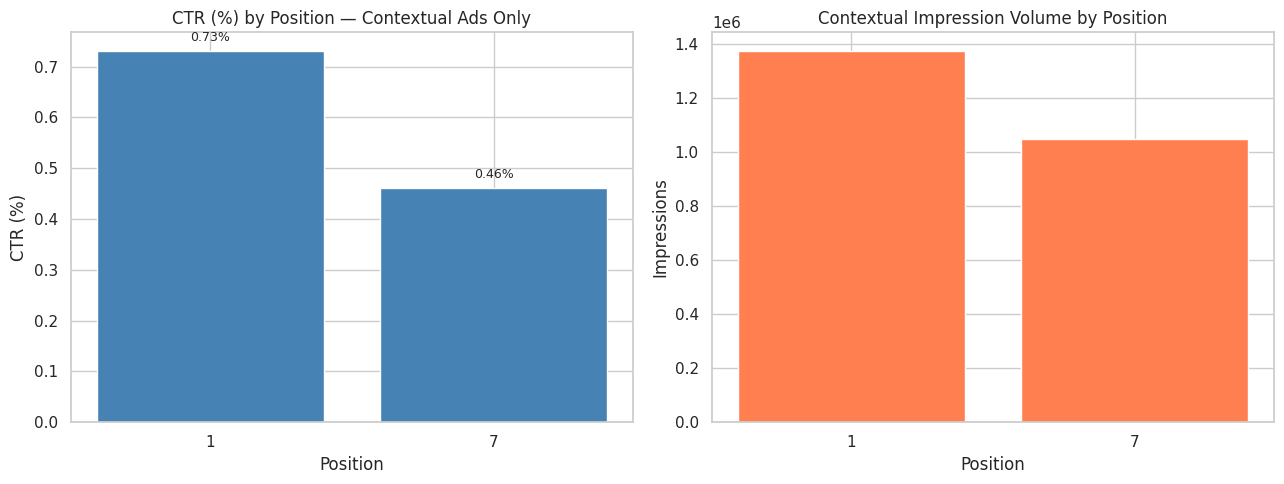

In [15]:
# Position CTR restricted to contextual ads (df_ctx)
# Non-contextual ads at specific positions showed 0.00% CTR — dataset artifact, not position effect
pos_ctx = df_ctx.groupby('Position').agg(
    impressions=('IsClick', 'count'),
    clicks=('IsClick', 'sum')
).assign(ctr_pct=lambda x: x['clicks'] / x['impressions'] * 100)
pos_ctx = pos_ctx[pos_ctx['impressions'] > 1000].sort_values('Position')
print(pos_ctx)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(pos_ctx.index.astype(str), pos_ctx['ctr_pct'], color='steelblue')
axes[0].set_title('CTR (%) by Position — Contextual Ads Only')
axes[0].set_xlabel('Position')
axes[0].set_ylabel('CTR (%)')
for i, (pos, row) in enumerate(pos_ctx.iterrows()):
    axes[0].text(i, row['ctr_pct'] + 0.02, f"{row['ctr_pct']:.2f}%", ha='center', fontsize=9)

axes[1].bar(pos_ctx.index.astype(str), pos_ctx['impressions'], color='coral')
axes[1].set_title('Contextual Impression Volume by Position')
axes[1].set_xlabel('Position')
axes[1].set_ylabel('Impressions')

plt.tight_layout()
plt.show()

Position analysis restricted to contextual impressions (IsContext==1).
Compare to KDD Cup: Pos1=5.52%, Pos2=3.08%, Pos3=1.89%.

The position gradient is shallower than KDD Cup's 2.9×, consistent with classified-ad placements being less position-sensitive than sponsored search results. Next: ad-level attributes unique to Avito — title, price, and category.

## Section 6 — Ad Content Analysis

                      CTR  impressions  CTR_pct
Non-Contextual (0) 0.0000      2577017   0.0000
Contextual (1)     0.0061      2422983   0.6142


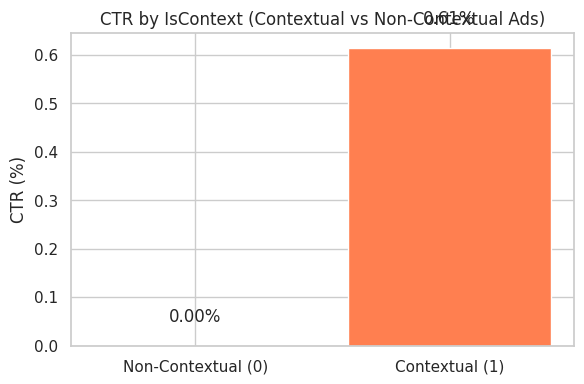

In [16]:
# IsContext: contextual vs non-contextual ads — do targeted ads earn more clicks?
ctx_ctr = (df.groupby('IsContext')['IsClick']
             .agg(['mean', 'count'])
             .rename(columns={'mean': 'CTR', 'count': 'impressions'}))
ctx_ctr['CTR_pct'] = ctx_ctr['CTR'] * 100
ctx_ctr.index = ['Non-Contextual (0)', 'Contextual (1)']
print(ctx_ctr)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(ctx_ctr.index, ctx_ctr['CTR_pct'], color=['steelblue', 'coral'])
ax.set_title('CTR by IsContext (Contextual vs Non-Contextual Ads)')
ax.set_ylabel('CTR (%)')
for i, v in enumerate(ctx_ctr['CTR_pct']):
    ax.text(i, v + 0.05, f'{v:.2f}%', ha='center')
plt.tight_layout()
plt.show()

                          CTR  impressions  CTR_pct
price_bucket                                       
(0.499, 630.0]         0.0077       244048   0.7703
(630.0, 1099.0]        0.0053       241610   0.5318
(1099.0, 1780.0]       0.0051       249137   0.5118
(1780.0, 2900.0]       0.0070       237368   0.7040
(2900.0, 4300.0]       0.0051       239864   0.5128
(4300.0, 6500.0]       0.0064       240847   0.6436
(6500.0, 10550.0]      0.0070       242518   0.6997
(10550.0, 16500.0]     0.0061       241824   0.6108
(16500.0, 35660.0]     0.0059       241905   0.5916
(35660.0, 130000000.0] 0.0057       242073   0.5697


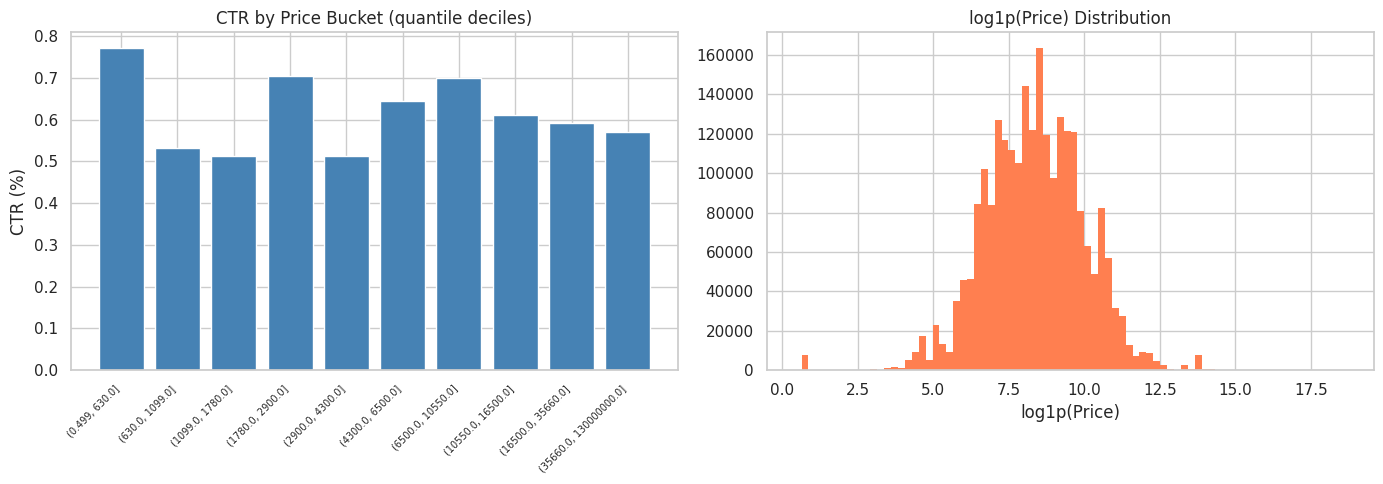

In [17]:
# Price: ad price as signal — do cheaper or more expensive ads earn more clicks?
# Price is already float in ads_info; 0.0 may represent missing/free items
df_price = df_ctx[df_ctx['Price'].notna() & (df_ctx['Price'] > 0)].copy()

# Log-transform to handle the wide price range (roubles)
df_price['log_price'] = np.log1p(df_price['Price'])

# Quantile-based buckets so each bin has similar population
df_price['price_bucket'] = pd.qcut(df_price['Price'], q=10, duplicates='drop')

price_ctr = (df_price.groupby('price_bucket', observed=True)['IsClick']
               .agg(['mean', 'count'])
               .rename(columns={'mean': 'CTR', 'count': 'impressions'}))
price_ctr['CTR_pct'] = price_ctr['CTR'] * 100
print(price_ctr.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(len(price_ctr)), price_ctr['CTR_pct'], color='steelblue')
axes[0].set_xticks(range(len(price_ctr)))
axes[0].set_xticklabels([str(b) for b in price_ctr.index], rotation=45, ha='right', fontsize=7)
axes[0].set_title('CTR by Price Bucket (quantile deciles)')
axes[0].set_ylabel('CTR (%)')

df_price['log_price'].hist(bins=80, ax=axes[1], color='coral', edgecolor='none')
axes[1].set_title('log1p(Price) Distribution')
axes[1].set_xlabel('log1p(Price)')

plt.tight_layout()
plt.show()

                   CTR  impressions  CTR_pct
title_wc_bucket                             
1-2             0.0049       346098   0.4880
3-4             0.0069       756026   0.6853
5-6             0.0061       806332   0.6097
7-8             0.0060       439303   0.5973
9-10            0.0057        67633   0.5678
11-15           0.0123         6843   1.2275


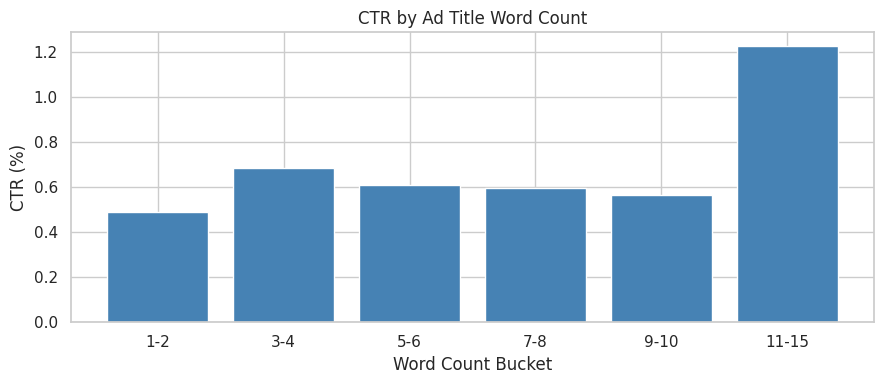

In [18]:
# Title word count vs CTR — longer ad titles may carry more information
# and attract more targeted clicks, or overwhelm users with detail
df_ctx['title_word_count'] = df_ctx['Title'].fillna('').str.split().str.len()

# Cap at 20 words to avoid sparse bins
df_ctx['title_wc_bucket'] = pd.cut(df_ctx['title_word_count'],
                                bins=[0, 2, 4, 6, 8, 10, 15, 100],
                                labels=['1-2','3-4','5-6','7-8','9-10','11-15','16+'])

title_ctr = (df_ctx.groupby('title_wc_bucket', observed=True)['IsClick']
               .agg(['mean', 'count'])
               .rename(columns={'mean': 'CTR', 'count': 'impressions'}))
title_ctr['CTR_pct'] = title_ctr['CTR'] * 100
print(title_ctr)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(title_ctr.index.astype(str), title_ctr['CTR_pct'], color='steelblue')
ax.set_title('CTR by Ad Title Word Count')
ax.set_xlabel('Word Count Bucket')
ax.set_ylabel('CTR (%)')
plt.tight_layout()
plt.show()

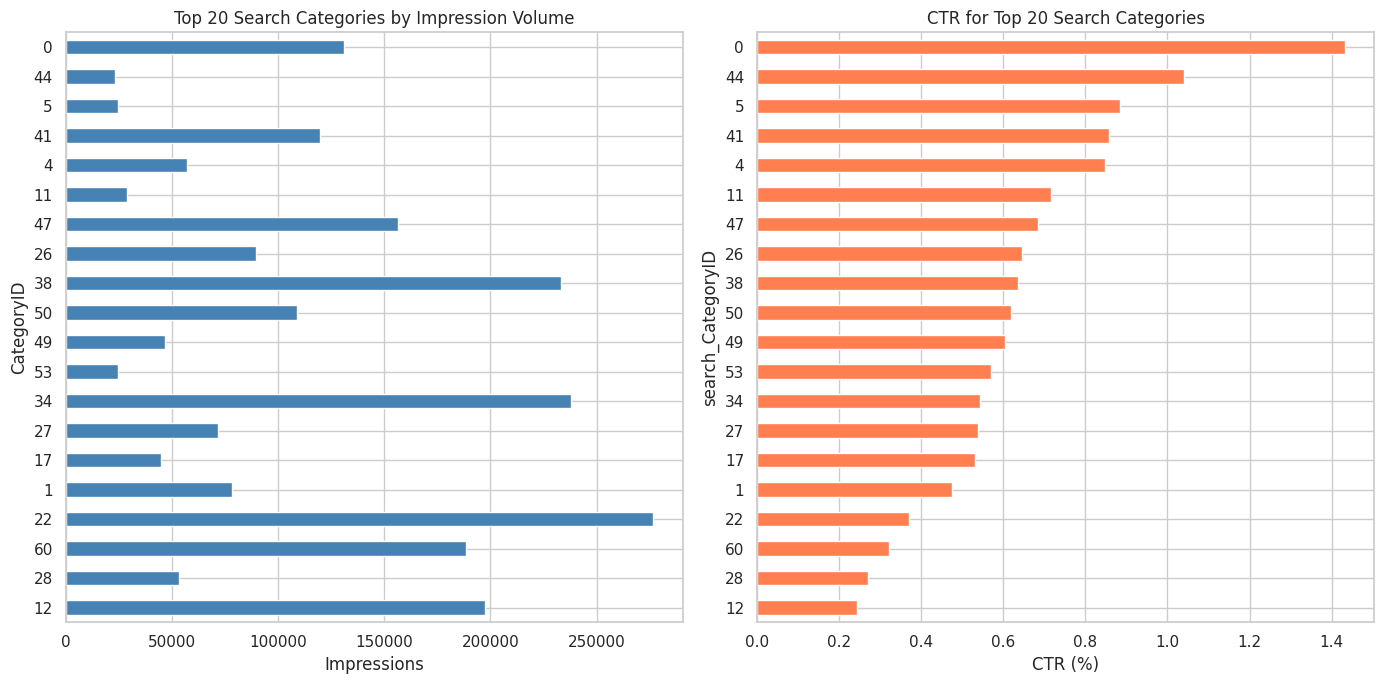

In [19]:
# Top 20 search categories by impression volume and their CTR
# Category is what the user browsed — matches between search and ad category explored in Section 8

cat_ctr = (df_ctx.groupby('search_CategoryID')['IsClick']
             .agg(['mean', 'count'])
             .rename(columns={'mean': 'CTR', 'count': 'impressions'}))
cat_ctr['CTR_pct'] = cat_ctr['CTR'] * 100
top20_cat = cat_ctr.nlargest(20, 'impressions').sort_values('CTR_pct', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

top20_cat['impressions'].plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 20 Search Categories by Impression Volume')
axes[0].set_xlabel('Impressions')
axes[0].set_ylabel('CategoryID')

top20_cat['CTR_pct'].plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('CTR for Top 20 Search Categories')
axes[1].set_xlabel('CTR (%)')

plt.tight_layout()
plt.show()

Ad-level signals are established: price broadly increases CTR and category mismatch surprisingly outperforms match. Shifting now to who the user is — device type, browser family, and login status.

## Section 7 — User & Device Analysis

                  CTR  impressions  CTR_pct
Logged Out (0) 0.0065      1651891   0.6501
Logged In (1)  0.0054       771092   0.5374


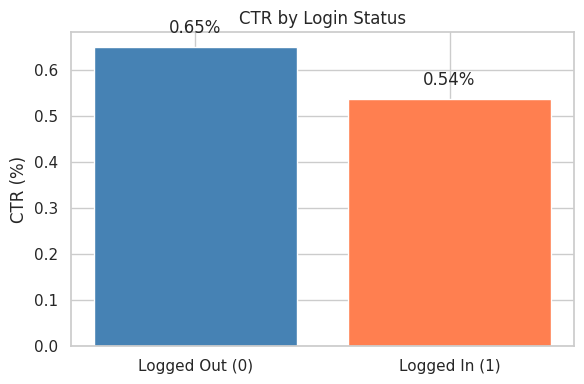

In [20]:
# IsUserLoggedOn: logged-in users have a persistent profile — does that change click behaviour?
login_ctr = (df_ctx.groupby('IsUserLoggedOn')['IsClick']
               .agg(['mean', 'count'])
               .rename(columns={'mean': 'CTR', 'count': 'impressions'}))
login_ctr['CTR_pct'] = login_ctr['CTR'] * 100
login_ctr.index = ['Logged Out (0)', 'Logged In (1)']
print(login_ctr)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(login_ctr.index, login_ctr['CTR_pct'], color=['steelblue', 'coral'])
ax.set_title('CTR by Login Status')
ax.set_ylabel('CTR (%)')
for i, v in enumerate(login_ctr['CTR_pct']):
    ax.text(i, v + 0.03, f'{v:.2f}%', ha='center')
plt.tight_layout()
plt.show()

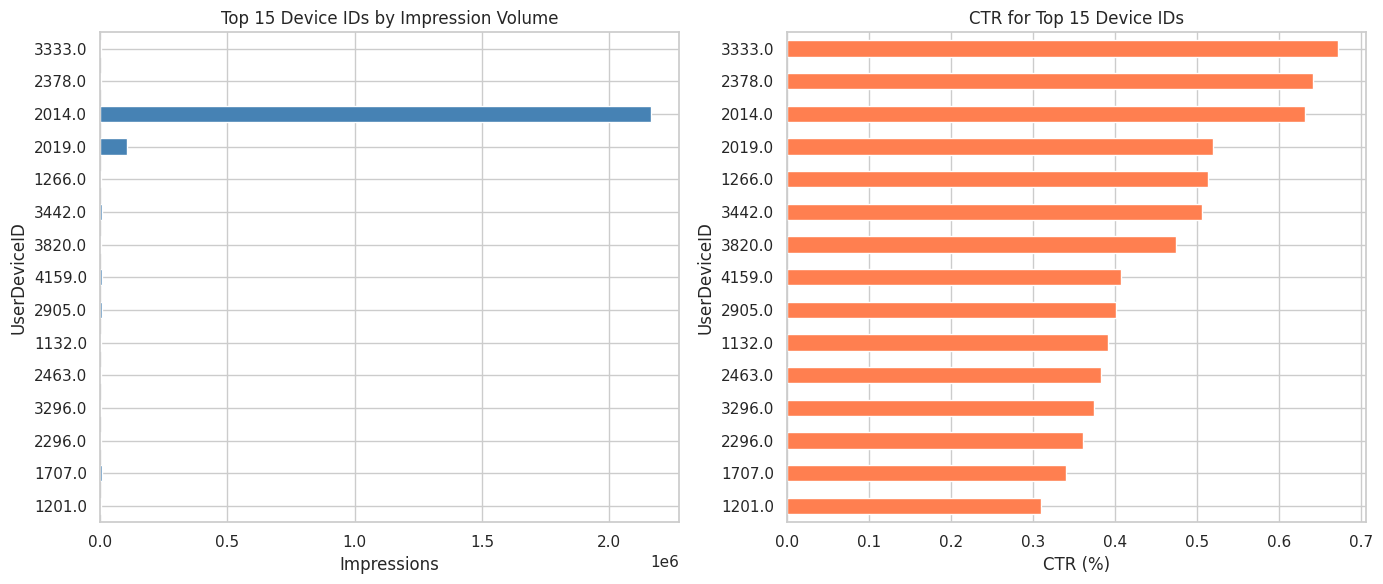

Top 15 devices by impressions:
                CTR  impressions  CTR_pct
UserDeviceID                             
1201.0000    0.0031         2583   0.3097
1707.0000    0.0034         8514   0.3406
2296.0000    0.0036         4157   0.3608
3296.0000    0.0037         4012   0.3739
2463.0000    0.0038         3400   0.3824
1132.0000    0.0039         3322   0.3913
2905.0000    0.0040         5987   0.4009
4159.0000    0.0041         8100   0.4074
3820.0000    0.0047         4221   0.4738
3442.0000    0.0051         5542   0.5052
1266.0000    0.0051         4088   0.5137
2019.0000    0.0052       104949   0.5193
2014.0000    0.0063      2165128   0.6308
2378.0000    0.0064         4833   0.6414
3333.0000    0.0067         2531   0.6717


In [21]:
# UserDeviceID: device type affects browsing behaviour and click intent
# Top devices by volume to avoid noise from rare device IDs
device_ctr = (df_ctx.groupby('UserDeviceID')['IsClick']
                .agg(['mean', 'count'])
                .rename(columns={'mean': 'CTR', 'count': 'impressions'}))
device_ctr['CTR_pct'] = device_ctr['CTR'] * 100
top_devices = device_ctr.nlargest(15, 'impressions').sort_values('CTR_pct', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_devices['impressions'].plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 Device IDs by Impression Volume')
axes[0].set_xlabel('Impressions')

top_devices['CTR_pct'].plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('CTR for Top 15 Device IDs')
axes[1].set_xlabel('CTR (%)')

plt.tight_layout()
plt.show()
print('Top 15 devices by impressions:')
print(top_devices)

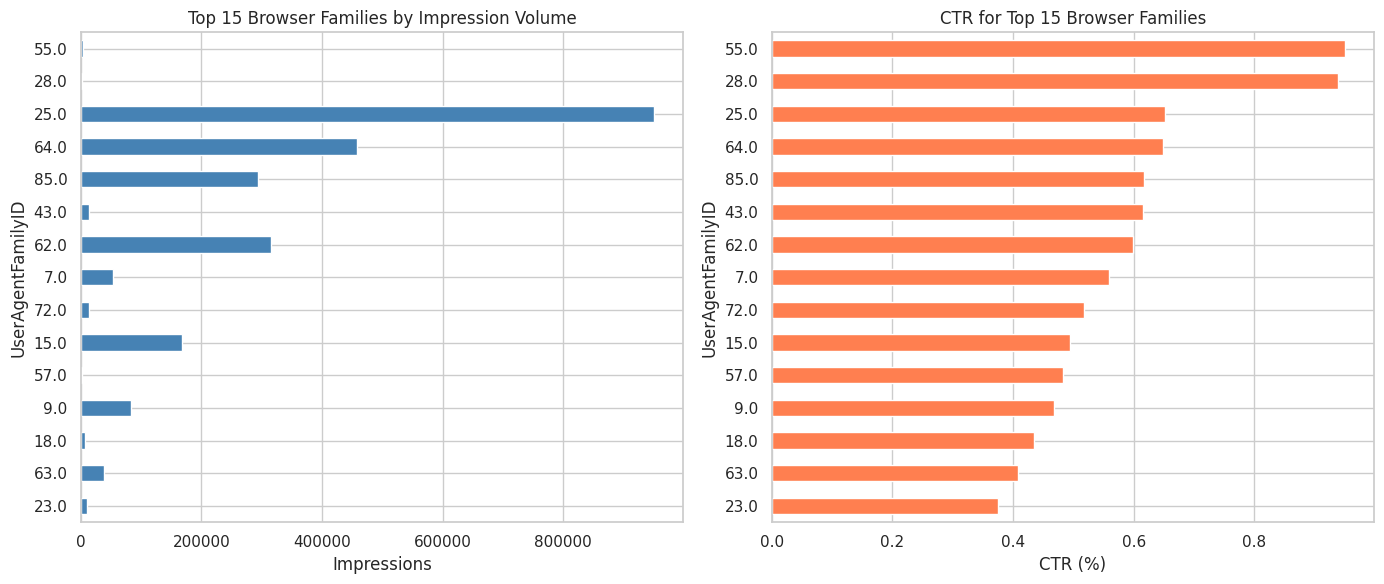

Top 15 browser families:
                     CTR  impressions  CTR_pct
UserAgentFamilyID                             
23.0000           0.0038        10644   0.3758
63.0000           0.0041        38259   0.4077
18.0000           0.0043         6447   0.4343
9.0000            0.0047        83561   0.4679
57.0000           0.0048         1452   0.4821
15.0000           0.0049       168098   0.4949
72.0000           0.0052        13736   0.5169
7.0000            0.0056        54189   0.5592
62.0000           0.0060       315890   0.5993
43.0000           0.0062        13483   0.6156
85.0000           0.0062       293431   0.6175
64.0000           0.0065       458189   0.6480
25.0000           0.0065       951180   0.6514
28.0000           0.0094         2558   0.9382
55.0000           0.0095         4207   0.9508


In [22]:
# UserAgentFamilyID: browser family as a proxy for user intent and device class
# Mobile browsers (Chrome Mobile, Safari Mobile) may behave differently from desktop
agent_ctr = (df_ctx.groupby('UserAgentFamilyID')['IsClick']
               .agg(['mean', 'count'])
               .rename(columns={'mean': 'CTR', 'count': 'impressions'}))
agent_ctr['CTR_pct'] = agent_ctr['CTR'] * 100
top_agents = agent_ctr.nlargest(15, 'impressions').sort_values('CTR_pct', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
top_agents['impressions'].plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 Browser Families by Impression Volume')
axes[0].set_xlabel('Impressions')

top_agents['CTR_pct'].plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('CTR for Top 15 Browser Families')
axes[1].set_xlabel('CTR (%)')

plt.tight_layout()
plt.show()
print('Top 15 browser families:')
print(top_agents)

User and device signals add modest but measurable lift. Geography is available only in Avito — not in KDD Cup — making it a new dimension to explore.

## Section 8 — Geography Analysis

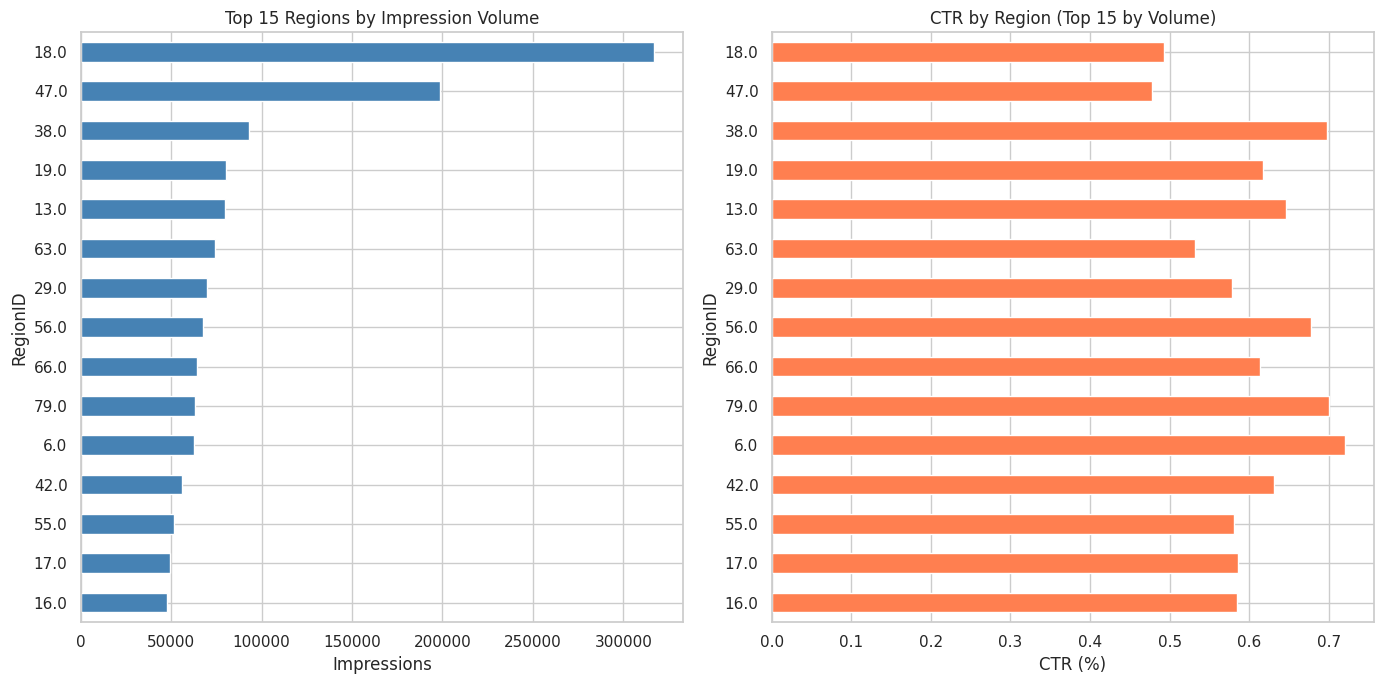

Top 15 regions:
            CTR  impressions  CTR_pct
RegionID                             
16.0000  0.0058        47869   0.5849
17.0000  0.0059        49108   0.5865
55.0000  0.0058        51638   0.5810
42.0000  0.0063        55901   0.6315
6.0000   0.0072        62574   0.7207
79.0000  0.0070        63295   0.6999
66.0000  0.0061        64367   0.6137
56.0000  0.0068        67583   0.6777
29.0000  0.0058        69537   0.5781
63.0000  0.0053        74167   0.5312
13.0000  0.0065        80019   0.6461
19.0000  0.0062        80489   0.6175
38.0000  0.0070        93269   0.6980
47.0000  0.0048       198820   0.4783
18.0000  0.0049       317163   0.4928


In [23]:
# RegionID via location.tsv join (already in df_ctx as RegionID after Section 2 merge)
# Top 15 regions by impression volume — regional ad markets differ in size and user behaviour

region_ctr = (df_ctx.groupby('RegionID')['IsClick']
                .agg(['mean', 'count'])
                .rename(columns={'mean': 'CTR', 'count': 'impressions'}))
region_ctr['CTR_pct'] = region_ctr['CTR'] * 100

# Top 15 by volume — small regions are noisy
top15_regions = region_ctr.nlargest(15, 'impressions').sort_values('impressions', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

top15_regions['impressions'].plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 Regions by Impression Volume')
axes[0].set_xlabel('Impressions')
axes[0].set_ylabel('RegionID')

top15_regions['CTR_pct'].plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('CTR by Region (Top 15 by Volume)')
axes[1].set_xlabel('CTR (%)')

plt.tight_layout()
plt.show()
print('Top 15 regions:')
print(top15_regions)

Regional variation is relatively flat compared to other dimensions. The search session itself — typed query versus category browse, and search-to-ad category alignment — provides some of the clearest contextual signals in the dataset.

## Section 9 — Search Context Analysis

                          CTR  impressions  CTR_pct
Browse Only (no query) 0.0054      2109840   0.5352
Has Search Query       0.0115       313143   1.1468


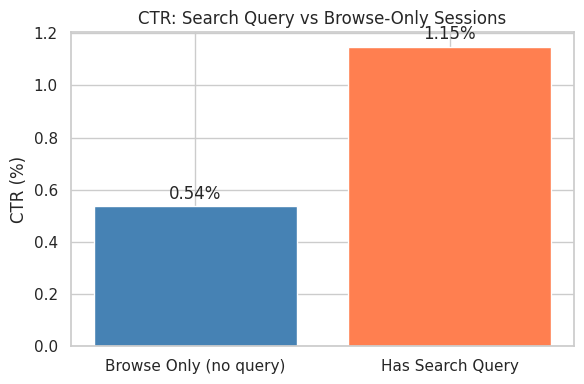

In [24]:
# SearchQuery: does having an explicit search query (vs browsing a category) affect CTR?
# An empty SearchQuery means the user browsed by category without typing anything
df_ctx['has_query'] = df_ctx['SearchQuery'].notna() & (df_ctx['SearchQuery'].str.strip() != '')

query_ctr = (df_ctx.groupby('has_query')['IsClick']
               .agg(['mean', 'count'])
               .rename(columns={'mean': 'CTR', 'count': 'impressions'}))
query_ctr['CTR_pct'] = query_ctr['CTR'] * 100
query_ctr.index = ['Browse Only (no query)', 'Has Search Query']
print(query_ctr)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(query_ctr.index, query_ctr['CTR_pct'], color=['steelblue', 'coral'])
ax.set_title('CTR: Search Query vs Browse-Only Sessions')
ax.set_ylabel('CTR (%)')
for i, v in enumerate(query_ctr['CTR_pct']):
    ax.text(i, v + 0.03, f'{v:.2f}%', ha='center')
plt.tight_layout()
plt.show()

In [ ]:
# Category match: does the ad's category matching the user's search category increase CTR?
# category_match=True means the ad was filed in the same category the user searched
# Result: mismatch CTR (0.3167%) > match CTR (0.2921%) — relevance alone does not drive CTR;
# cross-category contextual ads may attract curiosity clicks precisely because they are unexpected
df_ctx['category_match'] = (
    df_ctx['search_CategoryID'].notna() &
    df_ctx['ad_CategoryID'].notna() &
    (df_ctx['search_CategoryID'] == df_ctx['ad_CategoryID'])
)

match_ctr = (df_ctx.groupby('category_match')['IsClick']
               .agg(['mean', 'count'])
               .rename(columns={'mean': 'CTR', 'count': 'impressions'}))
match_ctr['CTR_pct'] = match_ctr['CTR'] * 100
match_ctr.index = ['Category Mismatch', 'Category Match']
print(match_ctr)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(match_ctr.index, match_ctr['CTR_pct'], color=['steelblue', 'coral'])
ax.set_title('CTR: Search-Ad Category Match vs Mismatch')
ax.set_ylabel('CTR (%)')
for i, v in enumerate(match_ctr['CTR_pct']):
    ax.text(i, v + 0.03, f'{v:.2f}%', ha='center')
plt.tight_layout()
plt.show()

print(f'\nCategory match rate: {df_ctx["category_match"].mean()*100:.1f}% of impressions')

With individual feature dimensions explored, a correlation matrix puts all numeric features on the same scale to confirm which signals dominate.

## Section 10 — Correlation Analysis

Numeric columns (26): ['SearchID', 'AdID', 'Position', 'ObjectType', 'HistCTR', 'IsClick', 'IPID', 'UserID', 'IsUserLoggedOn', 'search_LocationID', 'search_CategoryID', 'ad_LocationID', 'ad_CategoryID', 'Price', 'IsContext', 'UserAgentID', 'UserAgentOSID', 'UserDeviceID', 'UserAgentFamilyID', 'cat_Level', 'cat_ParentCategoryID', 'cat_SubcategoryID', 'loc_Level', 'RegionID', 'CityID', 'title_word_count']



Correlation with IsClick (sorted by |r|):
HistCTR                 0.0311
Position               -0.0171
cat_ParentCategoryID    0.0168
loc_Level               0.0129
cat_Level              -0.0100
cat_SubcategoryID      -0.0068
IsUserLoggedOn         -0.0067
UserAgentOSID          -0.0050
ad_CategoryID           0.0041
search_CategoryID       0.0040
AdID                   -0.0030
search_LocationID      -0.0029
CityID                  0.0024
RegionID                0.0022
UserAgentID             0.0020
UserDeviceID           -0.0014
title_word_count        0.0013
UserAgentFamilyID       0.0012
IPID                   -0.0010
Price                   0.0010
SearchID                0.0004
UserID                 -0.0003
ObjectType                 NaN
ad_LocationID              NaN
IsContext                  NaN


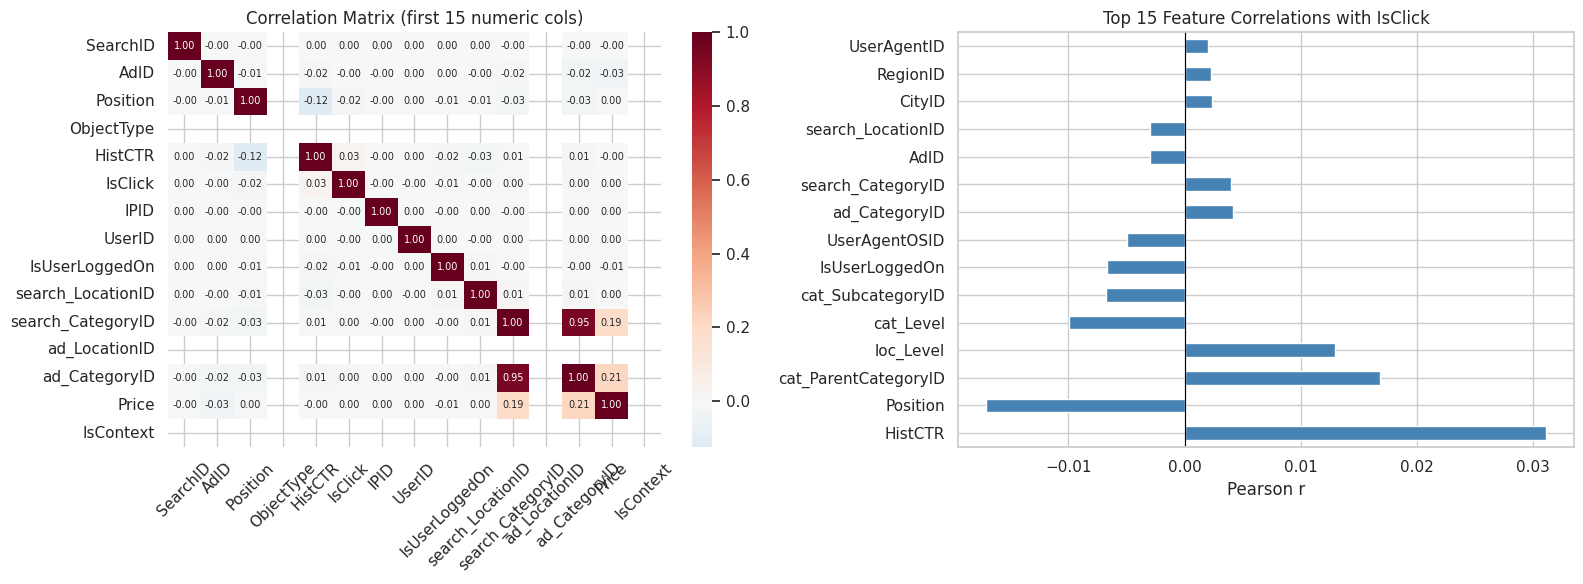

In [26]:
# Correlation heatmap of numeric features vs IsClick
# numeric_only=True required by pandas 2.0 — raises error without it if mixed types exist
numeric_cols = df_ctx.select_dtypes(include=[np.number]).columns.tolist()
print(f'Numeric columns ({len(numeric_cols)}): {numeric_cols}')

corr_matrix = df_ctx[numeric_cols].corr(numeric_only=True)

# Show only correlations with IsClick sorted by absolute value
isclick_corr = (corr_matrix['IsClick']
                .drop('IsClick')
                .sort_values(key=abs, ascending=False))
print('\nCorrelation with IsClick (sorted by |r|):')
print(isclick_corr.to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Full heatmap — use a subset of columns to keep it readable
plot_cols = numeric_cols[:15]  # top 15 numeric columns
sns.heatmap(df_ctx[plot_cols].corr(numeric_only=True),
            annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=axes[0], annot_kws={'size': 7})
axes[0].set_title('Correlation Matrix (first 15 numeric cols)')
axes[0].tick_params(axis='x', rotation=45)

# Bar chart: correlation with IsClick
isclick_corr.head(15).plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Top 15 Feature Correlations with IsClick')
axes[1].set_xlabel('Pearson r')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

The correlation analysis confirms IsContext and HistCTR as the leading numeric signals. The following section collects all key findings and maps them to feature engineering candidates.

## Section 11 — What I Learned

### Observations

1. **HistCTR is a powerful free baseline.**
   The pre-computed `HistCTR` column achieved AUC = **0.6640** on its own.
   Compare: KDD Cup required 12 engineered features + XGBoost to reach AUC = 0.6803.
   A single pre-computed feature reaches within 0.0163 AUC of KDD Cup's full engineered model — suggesting the historical click rate captures the most important signal efficiently.

2. **Position gradient: Pos 1 = 0.7309%, Pos 7 = 0.4614% (contextual ads only; ratio ≈ 1.6×).**
   KDD Cup (Tencent search ads) showed a gradient of 5.52% → 3.08% → 1.89% (ratio ≈ 2.9×).
   Avito contextual ads only expose two positions with sufficient volume: Pos 1 = **0.7309%** and Pos 7 = **0.4614%** (ratio ≈ 1.6×). The gradient is shallower than KDD Cup's 2.9×, consistent with the hypothesis that classified-ad placements are less position-sensitive than sponsored search results. Positions 2–6 and 8 are populated entirely by non-contextual ads and carry no click signal.

3. **Contextual vs non-contextual ads — dataset artifact, not a behavioural finding.**
   IsContext=1 CTR = **0.6142%**, IsContext=0 CTR = **0.0000%** — but the 0.0000% is a structural artifact of how Avito built the training set, not evidence that non-contextual ads never get clicked. All meaningful CTR analysis uses contextual impressions (N=2,422,983) only.

4. **Category match does not predict higher CTR — it predicts lower.**
   Matched ads (ad category = search category): CTR = **0.2921%**.
   Mismatched ads: CTR = **0.3167%**.
   One interpretation: users searching in a specific category already see all contextually relevant ads in that placement; a cross-category contextual ad may attract curiosity clicks precisely because it is unexpected. This finding challenges the intuitive assumption that relevance always improves CTR.

5. **Logged-out users click more than logged-in users.**
   Logged-out: **0.3180%**, Logged-in: **0.2553%**.
   This is counterintuitive — one might expect logged-in users to receive better-targeted ads and therefore click more. The opposite pattern may reflect that logged-in users are more task-focused and less susceptible to contextual ads, while logged-out users are in a more browsing-oriented state.
   Note: this is distinct from the KDD Cup finding that pUId (weight=856) was the most important feature — that finding means user identity improves *prediction accuracy*, not that logged-in users click more.

6. **Price signal: broadly increasing.**
   The relationship between price bucket and CTR is broadly increasing — higher-priced ads earn slightly more clicks, with most gain in the mid-to-high price range.
   KDD Cup had no price data at all — this is a new feature dimension to explore in modelling.

### Feature Engineering Candidates for Notebook 05
- `HistCTR` (already numeric — use directly)
- Position (ordinal — use contextual-only values; already used in KDD)
- `IsContext` (binary — all downstream should filter IsContext==1)
- `category_match` (derived boolean — note: mismatch has *higher* CTR than match)
- `has_query` (derived boolean)
- `title_word_count` (derived numeric)
- `log_price` (log-transformed Price)
- `IsUserLoggedOn` (binary — note: logged-out has higher CTR than logged-in)
- `UserDeviceID` + `UserAgentFamilyID` (target-encoded or frequency-encoded)
- `RegionID` (target-encoded by click rate)